In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Dataset

In [2]:
# Load the CSV dataset
csv_path = '/home/joao.lima/experiments/VAP/data/eval/vad_events.csv'
df = pd.read_csv(csv_path)

# Display basic info
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst few rows:')
df.head()

Dataset shape: (93891, 7)

Columns: ['ipu_end', 'tfo', 'speaker', 'label', 'audio_path', 'vad_path', 'relation']

First few rows:


,ipu_end,tfo,speaker,label,audio_path,vad_path,relation
0,44.02,0.78,1.0,shift,/hadatasets/joao.lima/data/seamless_interactio...,/hadatasets/joao.lima/data/seamless_interactio...,stranger
1,120.92,1.24,1.0,shift,/hadatasets/joao.lima/data/seamless_interactio...,/hadatasets/joao.lima/data/seamless_interactio...,stranger
2,189.46,3.40,1.0,shift,/hadatasets/joao.lima/data/seamless_interactio...,/hadatasets/joao.lima/data/seamless_interactio...,stranger
3,201.34,0.44,1.0,shift,/hadatasets/joao.lima/data/seamless_interactio...,/hadatasets/joao.lima/data/seamless_interactio...,stranger
4,246.32,0.16,1.0,shift,/hadatasets/joao.lima/data/seamless_interactio...,/hadatasets/joao.lima/data/seamless_interactio...,stranger


## Analysis: Shift/Hold Ratio by Relation Class

In [3]:
# Check unique values in label and relation columns
print('Unique labels:', df['label'].unique())
print('\nUnique relation classes:', df['relation'].unique())
print('\nLabel distribution overall:')
print(df['label'].value_counts())
print('\nRelation distribution overall:')
print(df['relation'].value_counts())

Unique labels: ['shift' 'hold']

Unique relation classes: ['stranger' 'romantic' 'coworkers' 'friends' 'familiar-generic'
 'family-generic' 'classmates' 'parent_child' 'siblings' 'neighbors']

Label distribution overall:
label
hold     83147
shift    10744
Name: count, dtype: int64

Relation distribution overall:
relation
stranger            46092
friends             27135
coworkers            7237
familiar-generic     5382
family-generic       4125
romantic             2693
classmates            916
parent_child          174
siblings               92
neighbors              45
Name: count, dtype: int64


In [4]:
# Calculate shift/hold counts and ratios per relation class
ratio_analysis = df.groupby(['relation', 'label']).size().unstack(fill_value=0)

# Calculate shift/hold ratio (shift / hold)
ratio_analysis['shift_hold_ratio'] = ratio_analysis['shift'] / ratio_analysis['hold']

# Calculate percentages
ratio_analysis['total'] = ratio_analysis['shift'] + ratio_analysis['hold']
ratio_analysis['shift_pct'] = (ratio_analysis['shift'] / ratio_analysis['total']) * 100
ratio_analysis['hold_pct'] = (ratio_analysis['hold'] / ratio_analysis['total']) * 100

print('Shift/Hold Analysis by Relation Class:')
print('='*80)
ratio_analysis

Shift/Hold Analysis by Relation Class:


label,hold,shift,shift_hold_ratio,total,shift_pct,hold_pct
relation,,,,,,
classmates,767,149,0.194263,916,16.266376,83.733624
coworkers,6502,735,0.113042,7237,10.156142,89.843858
familiar-generic,4820,562,0.116598,5382,10.442215,89.557785
family-generic,3560,565,0.158708,4125,13.696970,86.303030
friends,23512,3623,0.154092,27135,13.351760,86.648240
neighbors,39,6,0.153846,45,13.333333,86.666667
parent_child,154,20,0.129870,174,11.494253,88.505747
romantic,2343,350,0.149381,2693,12.996658,87.003342
siblings,87,5,0.057471,92,5.434783,94.565217


In [7]:
# Statistical test: Chi-square test for independence
# Create contingency table
contingency_table = pd.crosstab(df['relation'], df['label'])
print('Contingency Table:')
print(contingency_table)
print('\n')

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print('Chi-Square Test for Independence:')
print('='*80)
print(f'Chi-square statistic: {chi2:.4f}')
print(f'P-value: {p_value:.4e}')
print(f'Degrees of freedom: {dof}')
print('\nInterpretation:')
if p_value < 0.05:
    print('✓ There IS a statistically significant difference in shift/hold ratios')
    print('  across relation classes (p < 0.05)')
else:
    print('✗ There is NO statistically significant difference in shift/hold ratios')
    print('  across relation classes (p >= 0.05)')

Contingency Table:
label              hold  shift
relation                      
classmates          767    149
coworkers          6502    735
familiar-generic   4820    562
family-generic     3560    565
friends           23512   3623
neighbors            39      6
parent_child        154     20
romantic           2343    350
siblings             87      5
stranger          41363   4729


Chi-Square Test for Independence:
Chi-square statistic: 229.9299
P-value: 1.7021e-44
Degrees of freedom: 9

Interpretation:
✓ There IS a statistically significant difference in shift/hold ratios
  across relation classes (p < 0.05)


## Pairwise Comparisons

Since the chi-squared test shows significant differences, we now perform pairwise comparisons to identify which specific relation classes differ from each other.

In [9]:
import numpy as np

# Calculate standardized residuals from chi-square test
# Residuals > |2| or |3| indicate significant contribution to chi-square statistic
residuals = (contingency_table - expected) / np.sqrt(expected)

print('Standardized Residuals:')
print('='*80)
print('Values > |2| indicate significant deviation from expected (p < 0.05)')
print('Values > |3| indicate highly significant deviation (p < 0.01)\n')
print(residuals.round(3))

# Identify which relation classes have significant residuals
print('\n\nRelation classes with significant deviations:')
print('-'*80)
for relation in residuals.index:
    hold_res = residuals.loc[relation, 'hold']
    shift_res = residuals.loc[relation, 'shift']
    
    if abs(shift_res) > 2:
        direction = 'MORE' if shift_res > 0 else 'FEWER'
        significance = '***' if abs(shift_res) > 3 else '**'
        print(f'{relation:20s}: {direction} shifts than expected (z={shift_res:6.3f}) {significance}')

Standardized Residuals:
Values > |2| indicate significant deviation from expected (p < 0.05)
Values > |3| indicate highly significant deviation (p < 0.01)

label              hold  shift
relation                      
classmates       -1.551  4.315
coworkers         1.163 -3.236
familiar-generic  0.780 -2.171
family-generic   -1.538  4.279
friends          -3.341  9.295
neighbors        -0.135  0.375
parent_child     -0.007  0.020
romantic         -0.857  2.383
siblings          0.612 -1.704
stranger          2.699 -7.509


Relation classes with significant deviations:
--------------------------------------------------------------------------------
classmates          : MORE shifts than expected (z= 4.315) ***
coworkers           : FEWER shifts than expected (z=-3.236) ***
familiar-generic    : FEWER shifts than expected (z=-2.171) **
family-generic      : MORE shifts than expected (z= 4.279) ***
friends             : MORE shifts than expected (z= 9.295) ***
romantic            : MORE 

In [10]:
from itertools import combinations
from scipy.stats import chi2_contingency

# Perform pairwise chi-square tests with Bonferroni correction
relations = df['relation'].unique()
n_comparisons = len(list(combinations(relations, 2)))
bonferroni_alpha = 0.05 / n_comparisons

print(f'Pairwise Chi-Square Tests (Bonferroni corrected)')
print('='*80)
print(f'Number of comparisons: {n_comparisons}')
print(f'Bonferroni corrected alpha: {bonferroni_alpha:.6f}\n')

# Store results
pairwise_results = []

for rel1, rel2 in combinations(relations, 2):
    # Create 2x2 contingency table for this pair
    pair_data = df[df['relation'].isin([rel1, rel2])]
    pair_table = pd.crosstab(pair_data['relation'], pair_data['label'])
    
    # Perform chi-square test
    chi2_pair, p_pair, dof_pair, expected_pair = chi2_contingency(pair_table)
    
    # Calculate effect size (Cramér's V)
    n = pair_table.sum().sum()
    cramers_v = np.sqrt(chi2_pair / n)
    
    pairwise_results.append({
        'Relation 1': rel1,
        'Relation 2': rel2,
        'Chi2': chi2_pair,
        'p-value': p_pair,
        'Bonferroni Significant': p_pair < bonferroni_alpha,
        "Cramér's V": cramers_v
    })

# Convert to DataFrame and sort by p-value
pairwise_df = pd.DataFrame(pairwise_results).sort_values('p-value')

# Display significant pairs
significant_pairs = pairwise_df[pairwise_df['Bonferroni Significant']]
print(f'\nSignificant pairwise differences ({len(significant_pairs)} out of {n_comparisons}):')
print('-'*80)
if len(significant_pairs) > 0:
    display(significant_pairs)
else:
    print('No pairwise comparisons reached Bonferroni-corrected significance.')
    print('\nTop 10 comparisons by p-value:')
    display(pairwise_df.head(10))

Pairwise Chi-Square Tests (Bonferroni corrected)
Number of comparisons: 45
Bonferroni corrected alpha: 0.001111


Significant pairwise differences (12 out of 45):
--------------------------------------------------------------------------------


,Relation 1,Relation 2,Chi2,p-value,Bonferroni Significant,Cramér's V
2,stranger,friends,161.276592,5.952988e-37,True,0.046930
17,coworkers,friends,52.409465,4.505472e-13,True,0.039048
4,stranger,family-generic,47.062687,6.875216e-12,True,0.030613
5,stranger,classmates,34.198644,4.976361e-09,True,0.026972
24,friends,familiar-generic,33.645854,6.611566e-09,True,0.032167
19,coworkers,family-generic,32.161656,1.418630e-08,True,0.053204
20,coworkers,classmates,30.773317,2.899982e-08,True,0.061437
31,familiar-generic,classmates,25.934719,3.531599e-07,True,0.064171
30,familiar-generic,family-generic,23.363983,1.340654e-06,True,0.049574
0,stranger,romantic,20.138982,7.201390e-06,True,0.020318


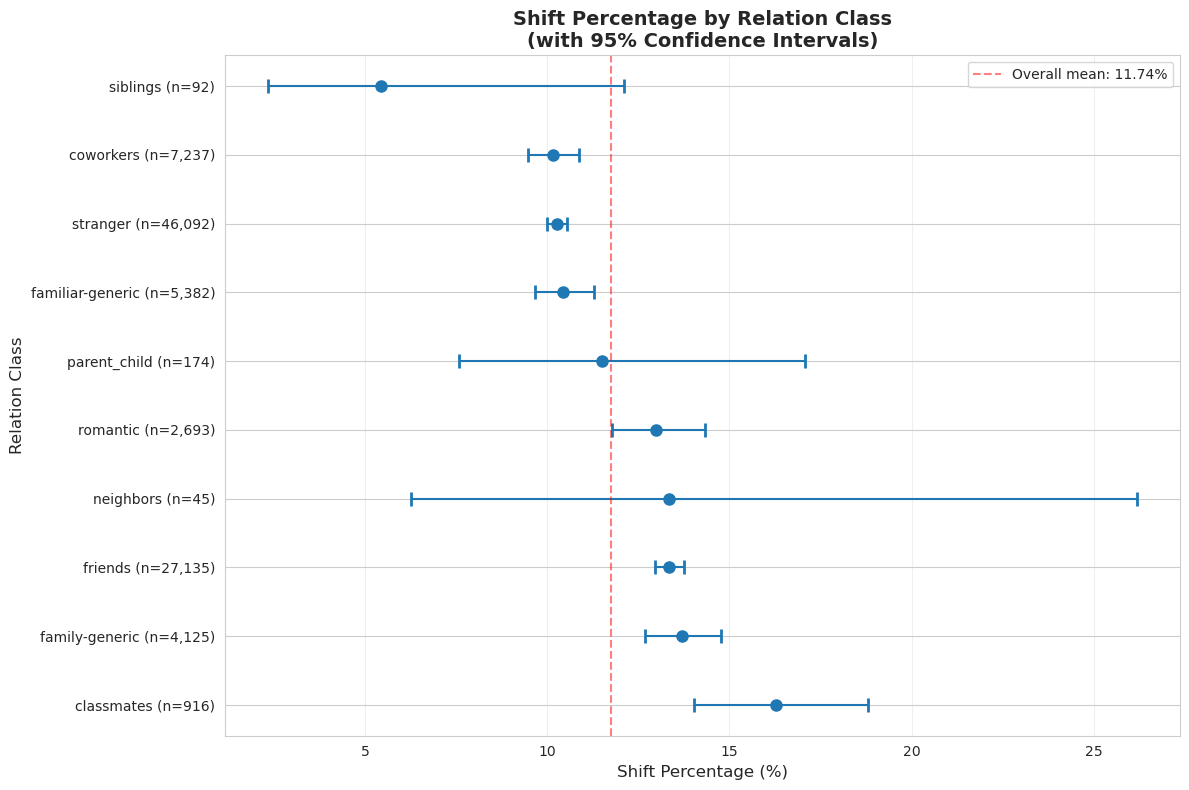


Shift percentages with 95% confidence intervals:
        relation  shift_pct  ci_lower  ci_upper  n_total
      classmates  16.266376 14.018067 18.796453      916
  family-generic  13.696970 12.681465 14.780029     4125
         friends  13.351760 12.952236 13.761659    27135
       neighbors  13.333333  6.257064 26.177582       45
        romantic  12.996658 11.779127 14.319610     2693
    parent_child  11.494253  7.565043 17.087007      174
familiar-generic  10.442215  9.653216 11.287645     5382
        stranger  10.259915  9.986200 10.540253    46092
       coworkers  10.156142  9.481183 10.873379     7237
        siblings   5.434783  2.343472 12.098691       92


In [11]:
# Visualize the shift percentages with confidence intervals
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Calculate confidence intervals for shift percentage
ci_data = []
for relation in ratio_analysis.index:
    n_shift = ratio_analysis.loc[relation, 'shift']
    n_total = ratio_analysis.loc[relation, 'total']
    
    # Wilson score interval for proportion
    p = n_shift / n_total
    z = 1.96  # 95% confidence
    denominator = 1 + z**2/n_total
    centre = (p + z**2/(2*n_total)) / denominator
    margin = z * np.sqrt(p*(1-p)/n_total + z**2/(4*n_total**2)) / denominator
    
    ci_data.append({
        'relation': relation,
        'shift_pct': p * 100,
        'ci_lower': (centre - margin) * 100,
        'ci_upper': (centre + margin) * 100,
        'n_total': n_total
    })

ci_df = pd.DataFrame(ci_data).sort_values('shift_pct', ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Plot points with error bars
y_pos = np.arange(len(ci_df))
ax.errorbar(ci_df['shift_pct'], y_pos, 
            xerr=[ci_df['shift_pct'] - ci_df['ci_lower'], 
                  ci_df['ci_upper'] - ci_df['shift_pct']],
            fmt='o', markersize=8, capsize=5, capthick=2)

# Customize
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r} (n={n:,})" for r, n in zip(ci_df['relation'], ci_df['n_total'])])
ax.set_xlabel('Shift Percentage (%)', fontsize=12)
ax.set_ylabel('Relation Class', fontsize=12)
ax.set_title('Shift Percentage by Relation Class\n(with 95% Confidence Intervals)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=ratio_analysis['shift_pct'].mean(), color='red', linestyle='--', 
           alpha=0.5, label=f'Overall mean: {ratio_analysis["shift_pct"].mean():.2f}%')
ax.legend()

plt.tight_layout()
plt.show()

print('\nShift percentages with 95% confidence intervals:')
print(ci_df[['relation', 'shift_pct', 'ci_lower', 'ci_upper', 'n_total']].to_string(index=False))

## Prediction analysis

In [16]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

df_preds_relCond = pd.read_csv('/home/joao.lima/experiments/VAP/data/eval/results/relCond/predictions.csv')
df_preds_baseline = pd.read_csv('/home/joao.lima/experiments/VAP/data/eval/results/baseline/predictions.csv')

def evaluate_performance(df, threshold=0.5):
    df_eval = df.copy()
    
    # Binarize predictions based on the threshold
    df_eval['pred_now'] = (df_eval['p_now'] >= threshold).astype(int)
    df_eval['pred_fut'] = (df_eval['p_fut'] >= threshold).astype(int)
    
    metrics = []
    for rel in df_eval['relation'].unique():
        subset = df_eval[df_eval['relation'] == rel]
        y_true = subset['target']
        
        if len(y_true) == 0:
            
            continue
            
        metrics.append({
            'relation': rel,
            'n_samples': len(subset),
            'bacc_now': balanced_accuracy_score(y_true, subset['pred_now']),
            'f1m_now': f1_score(y_true, subset['pred_now'], average='macro'),
            'bacc_fut': balanced_accuracy_score(y_true, subset['pred_fut']),
            'f1m_fut': f1_score(y_true, subset['pred_fut'], average='macro')
        })
        
    res_df = pd.DataFrame(metrics).sort_values('n_samples', ascending=False)
    return res_df

perf_df_relCond = evaluate_performance(df_preds_relCond)
perf_df_baseline = evaluate_performance(df_preds_baseline)

,relation,n_samples,bacc_now,f1m_now,bacc_fut,f1m_fut,relation_name
0,0,46092,0.751650,0.770000,0.783040,0.793869,stranger
3,3,27135,0.753064,0.777323,0.787340,0.801975,friends
2,2,7237,0.696782,0.716413,0.722964,0.743092,coworkers
4,4,5382,0.654887,0.686544,0.690239,0.715912,familiar-generic
5,5,4125,0.758410,0.784918,0.802728,0.812219,family-generic
1,1,2693,0.683686,0.700780,0.733621,0.742086,romantic
6,6,916,0.876705,0.860066,0.879505,0.855291,classmates
7,7,174,0.618506,0.658705,0.718506,0.769818,parent_child
8,8,92,0.571264,0.564898,0.754023,0.657738,siblings
9,9,45,0.666667,0.725610,0.666667,0.725610,neighbors


,relation,n_samples,bacc_now,f1m_now,bacc_fut,f1m_fut,relation_name
0,0,46092,0.770554,0.780117,0.785043,0.798193,stranger
3,3,27135,0.780688,0.788743,0.792858,0.802454,friends
2,2,7237,0.724531,0.741848,0.738019,0.757715,coworkers
4,4,5382,0.688220,0.720745,0.704131,0.735613,familiar-generic
5,5,4125,0.794875,0.813393,0.819641,0.826923,family-generic
1,1,2693,0.735969,0.747895,0.774048,0.775050,romantic
6,6,916,0.845659,0.848483,0.844911,0.852516,classmates
7,7,174,0.652273,0.674035,0.742532,0.737348,parent_child
8,8,92,0.788506,0.788506,0.682759,0.682759,siblings
9,9,45,0.583333,0.612737,0.653846,0.691358,neighbors


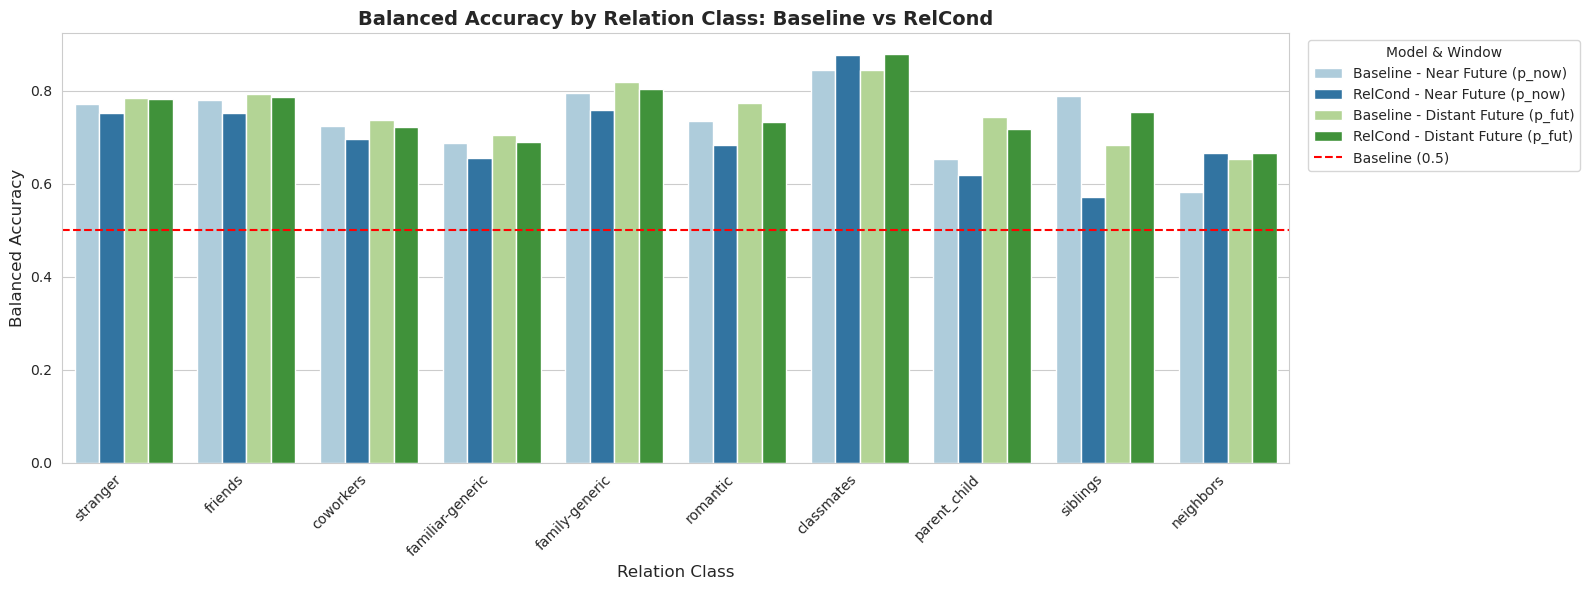

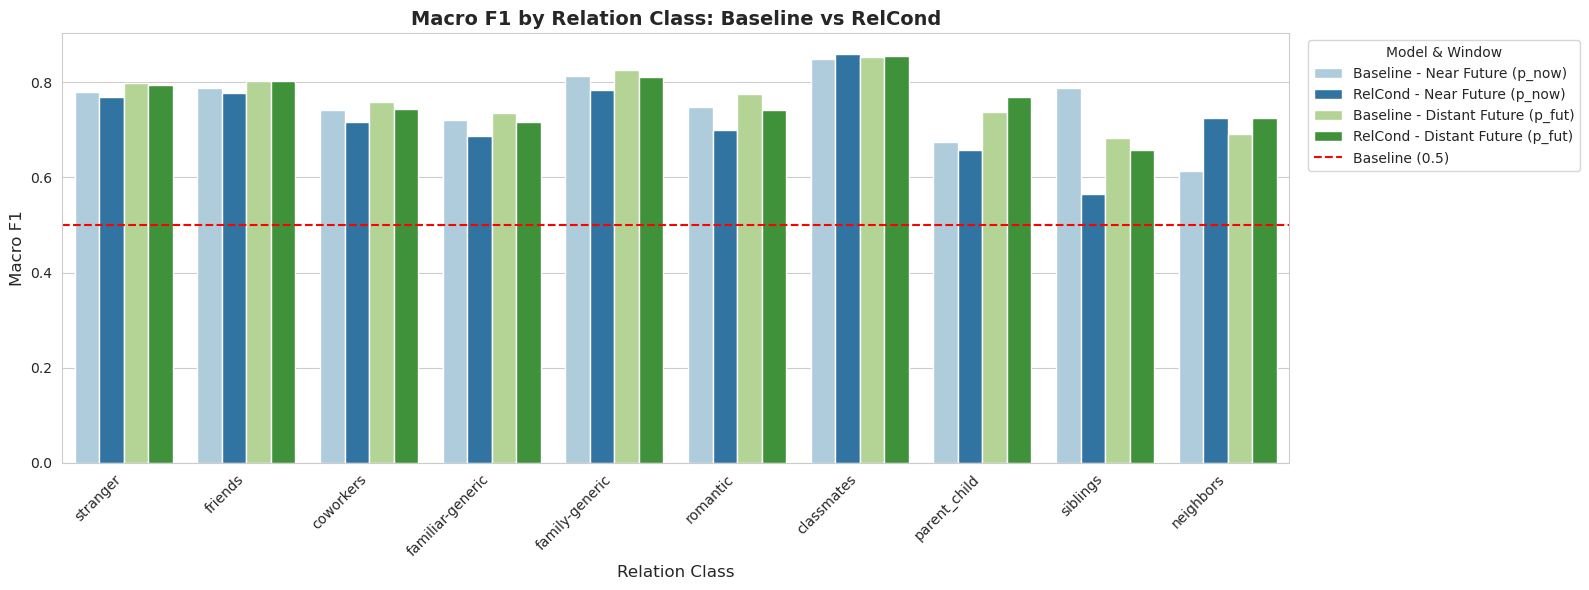

In [25]:
import json

# Load label mapping and invert it (id -> string name)
mapping_path = '/home/joao.lima/experiments/VAP/data/label_mapping.json'
with open(mapping_path, 'r') as f:
    label_mapping = json.load(f)
id_to_name = {int(v): k for k, v in label_mapping.items()}
perf_df_relCond['relation_name'] = perf_df_relCond['relation'].map(id_to_name)
perf_df_baseline['relation_name'] = perf_df_baseline['relation'].map(id_to_name)

display(perf_df_relCond)
display(perf_df_baseline)

def plot_performance_comparison(df_base, df_rel):
    # Create copies and add model label
    df_b = df_base.copy()
    df_r = df_rel.copy()
    df_b['Model'] = 'Baseline'
    df_r['Model'] = 'RelCond'
    
    # Combine dataframes
    df_combined = pd.concat([df_b, df_r])
    
    # --- Plot 1: Balanced Accuracy ---
    melted_bacc = df_combined.melt(
        id_vars=['relation_name', 'Model'], 
        value_vars=['bacc_now', 'bacc_fut'],
        var_name='Prediction Window', 
        value_name='Balanced Accuracy'
    )
    
    melted_bacc['Prediction Window'] = melted_bacc['Prediction Window'].map({
        'bacc_now': 'Near Future (p_now)', 
        'bacc_fut': 'Distant Future (p_fut)'
    })
    
    # Combine Model and Prediction Window for side-by-side bars
    melted_bacc['Condition'] = melted_bacc['Model'] + ' - ' + melted_bacc['Prediction Window']
    
    plt.figure(figsize=(16, 6))
    sns.barplot(
        data=melted_bacc, 
        x='relation_name', 
        y='Balanced Accuracy', 
        hue='Condition', 
        palette='Paired'
    )
    
    plt.title('Balanced Accuracy by Relation Class: Baseline vs RelCond', fontsize=14, fontweight='bold')
    plt.xlabel('Relation Class', fontsize=12)
    plt.ylabel('Balanced Accuracy', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0.5, color='red', linestyle='--', label='Baseline (0.5)')
    
    plt.legend(title='Model & Window', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Macro F1 ---
    melted_f1m = df_combined.melt(
        id_vars=['relation_name', 'Model'], 
        value_vars=['f1m_now', 'f1m_fut'],
        var_name='Prediction Window', 
        value_name='Macro F1'
    )
    
    melted_f1m['Prediction Window'] = melted_f1m['Prediction Window'].map({
        'f1m_now': 'Near Future (p_now)', 
        'f1m_fut': 'Distant Future (p_fut)'
    })
    
    melted_f1m['Condition'] = melted_f1m['Model'] + ' - ' + melted_f1m['Prediction Window']
    
    plt.figure(figsize=(16, 6))
    sns.barplot(
        data=melted_f1m, 
        x='relation_name', 
        y='Macro F1', 
        hue='Condition', 
        palette='Paired'
    )
    
    plt.title('Macro F1 by Relation Class: Baseline vs RelCond', fontsize=14, fontweight='bold')
    plt.xlabel('Relation Class', fontsize=12)
    plt.ylabel('Macro F1', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0.5, color='red', linestyle='--', label='Baseline (0.5)')
    
    plt.legend(title='Model & Window', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Call the standalone function with both dataframes
plot_performance_comparison(perf_df_baseline, perf_df_relCond)